In [1]:
# =========================================================
# PERTEMUAN 4 - STATISTIKA DASAR & ANALISA DATA
# Dataset Iris
# =========================================================

# =========================================================
# Import Library
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style visualisasi
sns.set(style='whitegrid')

# =========================================================
# LANGKAH 1 : LOAD & INSPECT DATASET
# =========================================================

# Load dataset iris
df = sns.load_dataset('iris')

# Menampilkan informasi dataset
print("===== INFORMASI DATASET =====")
print("Shape Dataset :", df.shape)

print("\n===== TIPE DATA =====")
print(df.dtypes)

print("\n===== 5 DATA TERATAS =====")
print(df.head())

print("\n===== STATISTIK DESKRIPTIF =====")
print(df.describe().round(3))

===== INFORMASI DATASET =====
Shape Dataset : (150, 5)

===== TIPE DATA =====
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

===== 5 DATA TERATAS =====
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

===== STATISTIK DESKRIPTIF =====
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1

In [2]:
# =========================================================
# LANGKAH 2 : STATISTIK DESKRIPTIF LENGKAP
# =========================================================

print("\n\n===== STATISTIK DESKRIPTIF LENGKAP =====")

for col_name in df.select_dtypes(include='number').columns:

    col = df[col_name]

    print(f'\n=== {col_name.upper()} ===')
    print(f'Mean      : {col.mean():.3f}')
    print(f'Median    : {col.median():.3f}')
    print(f'Std Dev   : {col.std():.3f}')
    print(f'Varians   : {col.var():.3f}')
    print(f'Skewness  : {col.skew():.3f}')
    print(f'Kurtosis  : {col.kurt():.3f}')



===== STATISTIK DESKRIPTIF LENGKAP =====

=== SEPAL_LENGTH ===
Mean      : 5.843
Median    : 5.800
Std Dev   : 0.828
Varians   : 0.686
Skewness  : 0.315
Kurtosis  : -0.552

=== SEPAL_WIDTH ===
Mean      : 3.057
Median    : 3.000
Std Dev   : 0.436
Varians   : 0.190
Skewness  : 0.319
Kurtosis  : 0.228

=== PETAL_LENGTH ===
Mean      : 3.758
Median    : 4.350
Std Dev   : 1.765
Varians   : 3.116
Skewness  : -0.275
Kurtosis  : -1.402

=== PETAL_WIDTH ===
Mean      : 1.199
Median    : 1.300
Std Dev   : 0.762
Varians   : 0.581
Skewness  : -0.103
Kurtosis  : -1.341


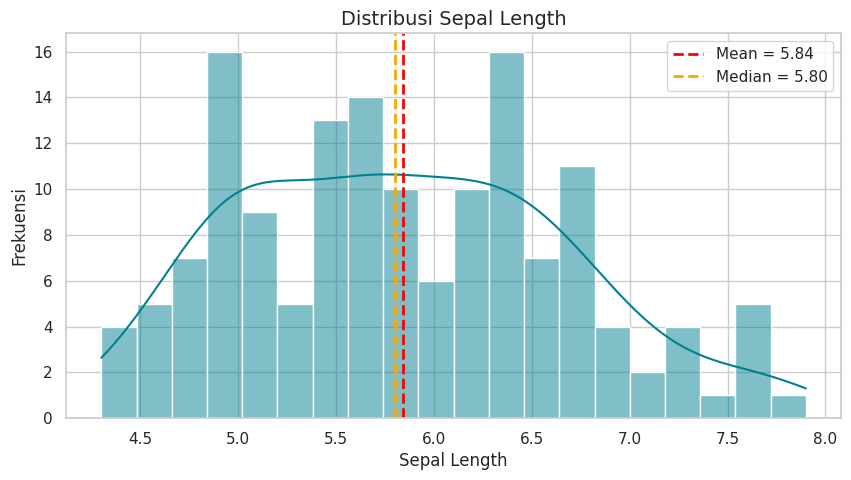


===== INTERPRETASI DISTRIBUSI =====
Nilai Skewness : 0.315
Distribusi cenderung miring ke kanan (positively skewed).


In [3]:
# =========================================================
# LANGKAH 3 : ANALISIS DISTRIBUSI
# Histogram + KDE
# =========================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df['sepal_length'],
    kde=True,
    bins=20,
    color='#028090',
    ax=ax
)

# Garis mean
ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis median
ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length', fontsize=14)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Frekuensi')

ax.legend()

plt.show()

# Interpretasi distribusi
print("\n===== INTERPRETASI DISTRIBUSI =====")

skew_value = df['sepal_length'].skew()

print(f"Nilai Skewness : {skew_value:.3f}")

if skew_value > 0:
    print("Distribusi cenderung miring ke kanan (positively skewed).")
elif skew_value < 0:
    print("Distribusi cenderung miring ke kiri (negatively skewed).")
else:
    print("Distribusi simetris.")

/tmp/ipykernel_6692/2770681599.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6692/2770681599.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


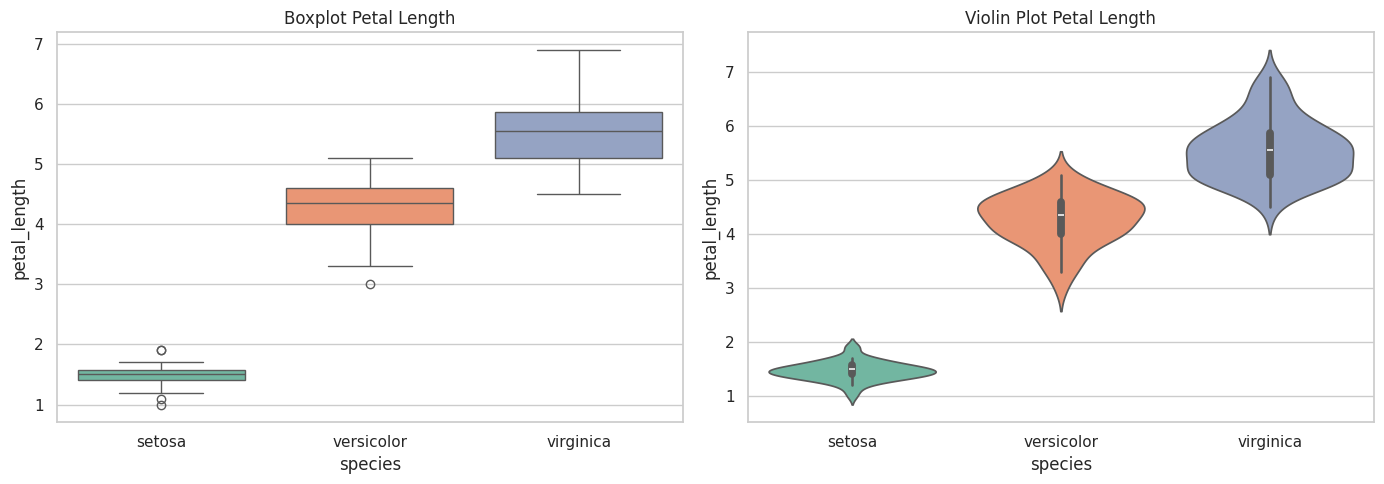


===== ANALISIS PETAL LENGTH =====
             mean  max  min    std
species                           
setosa      1.462  1.9  1.0  0.174
versicolor  4.260  5.1  3.0  0.470
virginica   5.552  6.9  4.5  0.552

Spesies dengan nilai terbesar : virginica
Spesies dengan nilai terkecil : setosa
Spesies paling tersebar       : virginica


In [4]:
# =========================================================
# LANGKAH 4 : BOXPLOT PER SPESIES
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title('Boxplot Petal Length')

# Violin plot
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

# Analisis spesies
print("\n===== ANALISIS PETAL LENGTH =====")

group_stats = df.groupby('species')['petal_length'].agg(['mean', 'max', 'min', 'std'])

print(group_stats.round(3))

largest_species = group_stats['max'].idxmax()
smallest_species = group_stats['min'].idxmin()
widest_species = group_stats['std'].idxmax()

print(f"\nSpesies dengan nilai terbesar : {largest_species}")
print(f"Spesies dengan nilai terkecil : {smallest_species}")
print(f"Spesies paling tersebar       : {widest_species}")

In [5]:
# =========================================================
# LANGKAH 5 : MATRIKS KORELASI PEARSON
# =========================================================

corr = df.drop('species', axis=1).corr(method='pearson')

print("\n===== MATRIKS KORELASI =====")
print(corr.round(3))

# Mencari korelasi tertinggi
mask = np.triu(np.ones(corr.shape, dtype=bool))

corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f'\nKorelasi tertinggi : {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}')



===== MATRIKS KORELASI =====
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi : ('petal_width', 'petal_length') = 0.963
Korelasi terendah  : ('petal_length', 'sepal_width') = -0.428


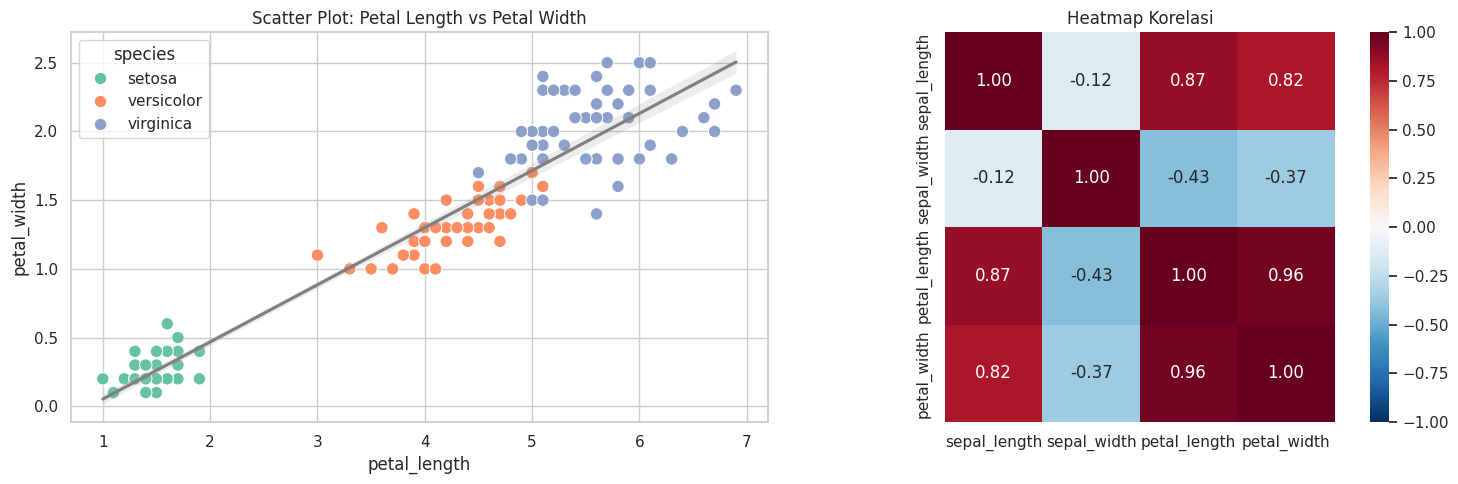

In [6]:
# =========================================================
# LANGKAH 6 : SCATTER PLOT & HEATMAP
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    s=80,
    ax=axes[0]
)

# Garis regresi
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0]
)

axes[0].set_title('Scatter Plot: Petal Length vs Petal Width')

# Heatmap korelasi
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()